# Empirical NTK tests for grokking on modular addition

This notebook runs the Tier 0 baseline from the G2 proposal and records the kernel measures the proposal defines. It reuses the dataset, model, kernel, scale, rotation and alignment code from `RepoducedCode.py` in this folder. It adds four things that the script does not have. It seeds the model separately from the data split. It computes the pre-registered grokking time with right censoring. It saves every run with its hyperparameters to `results/` so a run can be reloaded instead of repeated. It plots the results.

The baseline follows Kumar et al. (2024), Appendix 8.3, arXiv:2310.06110v3, which was read on 14 September 2026. That appendix fixes one hidden layer of width 100, input size 2p, output size p, mean squared error, full-batch gradient descent at learning rate 100, p equal to 23, 90 percent of the pairs for training, and no weight decay. It does not state the activation, the biases, the initialisation, or the parameterisation.

One finding of this notebook is that those unstated choices decide whether the run groks at all. With the PyTorch default initialisation used in `RepoducedCode.py`, learning rate 100 is unstable. The first update moves the parameters by about a quarter of their norm, the loss then oscillates from step to step, and the test loss never leaves chance. With the script's own seeding, where the model is built from the generator state left by the data split, every hidden unit died and the kernel norm went to zero within a few hundred steps. Kumar et al. write that their results agree with Gromov (2023), arXiv:2301.02679, and Gromov's Equations 1 and 2 define the network in mean-field parameterisation, with weights drawn from a standard normal, the first layer divided by the input size, and the output divided by the width. That parameterisation is used for the baseline here. Gromov uses a quadratic activation; ReLU is used here because the proposal's homogeneity argument is stated for a bias-free ReLU network. No biases are used, so the network is 2-homogeneous.

The learning rate is the second departure. In mean-field parameterisation the output is divided by the width, so the gradients are smaller by that factor and learning rate 100 barely moves the loss in 60,000 steps. Probe runs on 14 September 2026 with the same data split gave the following. At learning rate 100 the train loss went from 0.0435 to 0.0413 in 60,000 steps. At 1,000 the train loss crossed 0.002 at 60,000 steps. At 3,000 it crossed 0.001 near step 25,000. At 10,000 it crossed 0.001 near step 8,000. The curves at different rates have the same shape with time rescaled, so the rate sets the clock and not the dynamics. The notebook uses 10,000 as `ETA_0`. Kumar et al. plot a loss that starts at 1/p, which is the mean over samples and outputs, but they do not say how the loss used for the gradient was normalised, and a sum over the training set would change the effective rate by a factor of about 476. This departure should be discussed with the group before the sweeps are run.

Section 5 shows the dead run under the script's defaults. Sections 6 and 7 show the baseline and its kernel measures. Section 8 repeats the alpha sweep of Kumar et al., Figure 2(c).

In [1]:
import sys, json, math, time, copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from RepoducedCode import (
    make_modular_addition_dataset,
    ModularMLP,
    compute_entk,
    compute_scale_and_rotation,
    compute_task_alignment,
)

torch.set_num_threads(4)
DEVICE = "cpu"
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

# Set RERUN to True to discard saved runs and train again.
RERUN = False

# Thresholds for the grokking time. The proposal fixes the definition but
# not the values, so these are provisional and Section 6 reports the
# sensitivity to them. At 1e-3 the test loss of the baseline floors just
# above the threshold and every cell is censored, so 3e-3 is used here. Chance level for the mean squared error on
# one-hot targets with p classes is 1/p, which is about 0.0435 for p = 23.
TAU_TRAIN = 3e-3
TAU_TEST = 3e-3

# Base learning rate for the mean-field runs. See the note at the top.
ETA_0 = 10000.0
STEPS = 100000

# Plot settings. Colours follow a fixed categorical order so that train is
# always blue and test is always orange.
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
ALPHA_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "lines.linewidth": 2,
    "legend.frameon": False,
})

## 1. Models

`ModularMLP` from the script uses the PyTorch default initialisation, which is the standard parameterisation with uniform weights of scale one over the square root of the fan-in. `MeanFieldMLP` follows Gromov (2023), Equations 1 and 2. Both take the same arguments so the training loop can switch between them.

In [2]:
class MeanFieldMLP(nn.Module):
    """One hidden layer network in mean-field parameterisation.

    This follows Gromov (2023), Equations 1 and 2 (arXiv:2301.02679, read on
    14 September 2026). The hidden preactivation is W1 x divided by the input
    size D, and the output is W2 phi(h) divided by the width N. Both weight
    matrices are drawn from a standard normal distribution. Gromov uses a
    quadratic activation. ReLU is the default here because the proposal's
    homogeneity argument is stated for a bias-free ReLU network. There are no
    biases, so the network is 2-homogeneous in its parameters.
    """

    def __init__(self, input_dim, hidden_dim, output_dim, activation="relu"):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.activation = activation
        self.W1 = nn.Parameter(torch.randn(hidden_dim, input_dim))
        self.W2 = nn.Parameter(torch.randn(output_dim, hidden_dim))

    def forward(self, x):
        h = x @ self.W1.T / self.input_dim
        if self.activation == "relu":
            z = torch.relu(h)
        elif self.activation == "quadratic":
            z = h * h
        else:
            raise ValueError(self.activation)
        return z @ self.W2.T / self.hidden_dim


def build_model(parameterisation, input_dim, hidden_dim, output_dim, activation="relu"):
    """Return a fresh model. The caller sets the seed before calling this."""
    if parameterisation == "standard":
        return ModularMLP(input_dim, hidden_dim, output_dim)
    if parameterisation == "mean_field":
        return MeanFieldMLP(input_dim, hidden_dim, output_dim, activation)
    raise ValueError(parameterisation)

## 2. Training loop with checkpoints

The loop is the one in the script with a few changes. The model seed is separate from the data seed. The train loss is recorded after the update, at the same point as the test loss. Train and test accuracy are recorded as well, so the accuracy plot of Kumar et al., Figure 2(a), can be compared. The quantity y transposed K inverse y from the proposal is recorded using a pseudo-inverse of the probe kernel and summed over the p outputs. Each run is saved to `results/` as JSON with its full configuration.

The predictor is the centred and rescaled function of Kumar et al. (2024), Appendix 8.1, Equation 7, with learning rate eta_0 over alpha squared. Weight decay enters as a multiplicative factor of one minus eta times kappa per step, as in the script.

In [3]:
def train_run(name, parameterisation="mean_field", p=23, hidden_dim=100, alpha=1.0,
              eta_0=100.0, eta_kappa=0.0, steps=60000, eval_interval=250,
              probe_size=256, seed=0, data_seed=42, train_fraction=0.9,
              activation="relu", verbose=True):
    """Train one run and return a dictionary with the configuration and history."""
    config = dict(name=name, parameterisation=parameterisation, p=p, hidden_dim=hidden_dim,
                  alpha=alpha, eta_0=eta_0, eta_kappa=eta_kappa, steps=steps,
                  eval_interval=eval_interval, probe_size=probe_size, seed=seed,
                  data_seed=data_seed, train_fraction=train_fraction, activation=activation)

    # The dataset function seeds the generator itself, so the split depends only on data_seed.
    (X_train, y_train), (X_test, y_test) = make_modular_addition_dataset(
        p=p, train_fraction=train_fraction, seed=data_seed)
    X_train, y_train, X_test, y_test = [t.to(DEVICE) for t in (X_train, y_train, X_test, y_test)]

    # A fixed probe set from the training pairs, as in the script.
    probe_size = min(probe_size, X_train.shape[0])
    x_probe, y_probe = X_train[:probe_size], y_train[:probe_size]

    # Seed the model separately so several seeds can share one split.
    torch.manual_seed(seed)
    model = build_model(parameterisation, 2 * p, hidden_dim, p, activation).to(DEVICE)
    model_0 = copy.deepcopy(model)
    for q in model_0.parameters():
        q.requires_grad = False

    lr = eta_0 / alpha ** 2
    weight_decay = eta_kappa / lr
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    def predict(X):
        return alpha * (model(X) - model_0(X))

    params_0 = torch.cat([q.detach().flatten() for q in model.parameters()]).clone()
    K_0 = compute_entk(model, dict(model.named_parameters()), x_probe, mode="trace").detach()

    keys = ["step", "train_loss", "test_loss", "train_acc", "test_acc",
            "S_t", "R_t", "A_t", "param_dist", "yKy", "K_norm"]
    history = {k: [] for k in keys}

    def evaluate(step):
        model.eval()
        with torch.no_grad():
            tr, te = predict(X_train), predict(X_test)
            train_loss, test_loss = loss_fn(tr, y_train).item(), loss_fn(te, y_test).item()
            train_acc = (tr.argmax(1) == y_train.argmax(1)).float().mean().item()
            test_acc = (te.argmax(1) == y_test.argmax(1)).float().mean().item()
            params_t = torch.cat([q.flatten() for q in model.parameters()])
            param_dist = (torch.linalg.norm(params_t - params_0) / torch.linalg.norm(params_0)).item()
        K_t = compute_entk(model, dict(model.named_parameters()), x_probe, mode="trace").detach()
        S_t, R_t = compute_scale_and_rotation(K_0, K_t)
        A_t = compute_task_alignment(K_t, y_probe)
        K_norm = torch.linalg.norm(K_t, ord="fro").item()
        if K_norm > 0:
            K_pinv = torch.linalg.pinv(K_t, rtol=1e-6)
            yKy = torch.sum(y_probe * (K_pinv @ y_probe)).item()
        else:
            yKy = float("nan")
        for k, v in zip(keys, [step, train_loss, test_loss, train_acc, test_acc,
                               S_t, R_t, A_t, param_dist, yKy, K_norm]):
            history[k].append(v)
        model.train()

    t0 = time.time()
    evaluate(0)
    for step in range(1, steps + 1):
        optimizer.zero_grad()
        loss = loss_fn(predict(X_train), y_train)
        loss.backward()
        optimizer.step()
        if step % eval_interval == 0:
            evaluate(step)
            if verbose and step % (eval_interval * 40) == 0:
                h = history
                print(f"{name}: step {step:6d}  train {h['train_loss'][-1]:.2e}  test {h['test_loss'][-1]:.2e}  "
                      f"S {h['S_t'][-1]:+.2f}  R {h['R_t'][-1]:.3f}  A {h['A_t'][-1]:.3f}")
    run = dict(config=config, history=history, seconds=time.time() - t0)
    (RESULTS / f"{name}.json").write_text(json.dumps(run))
    if verbose:
        print(f"{name}: done in {run['seconds']:.0f} s, saved to results/{name}.json")
    return run


def run_or_load(name, **config):
    """Load a saved run if its configuration matches, otherwise train it."""
    path = RESULTS / f"{name}.json"
    if path.exists() and not RERUN:
        run = json.loads(path.read_text())
        saved = {k: v for k, v in run["config"].items() if k != "name"}
        defaults = dict(parameterisation="mean_field", p=23, hidden_dim=100, alpha=1.0,
                        eta_0=100.0, eta_kappa=0.0, steps=60000, eval_interval=250,
                        probe_size=256, seed=0, data_seed=42, train_fraction=0.9,
                        activation="relu")
        wanted = {**defaults, **config}
        if saved == wanted:
            print(f"{name}: loaded from results/{name}.json")
            return run
        print(f"{name}: saved configuration differs, training again")
    return train_run(name, **config)

## 3. Grokking time

The proposal pre-registers the grokking time as the number of steps between the training loss first falling below one threshold and the test loss first falling below another. A run whose test loss never falls below the threshold has not grokked. It is kept and its grokking time is recorded as a lower bound, which is right censoring. Losses are recorded every `eval_interval` steps, so each crossing is known to that resolution.

In [4]:
def first_crossing(steps, values, tau):
    """Return the first recorded step at which values fall below tau, or None."""
    values = np.asarray(values)
    below = np.where(values < tau)[0]
    return int(steps[below[0]]) if len(below) else None


def grokking_time(run, tau_train=TAU_TRAIN, tau_test=TAU_TEST):
    """Return the crossing steps and the grokking time, with a censoring flag."""
    h = run["history"]
    steps = np.asarray(h["step"])
    t_train = first_crossing(steps, h["train_loss"], tau_train)
    t_test = first_crossing(steps, h["test_loss"], tau_test)
    last = int(steps[-1])
    if t_train is None:
        return dict(t_train=None, t_test=t_test, t_grok=None, censored=True, last_step=last)
    if t_test is None:
        return dict(t_train=t_train, t_test=None, t_grok=last - t_train, censored=True, last_step=last)
    return dict(t_train=t_train, t_test=t_test, t_grok=t_test - t_train, censored=False, last_step=last)


def describe_grokking(run, tau_train=TAU_TRAIN, tau_test=TAU_TEST):
    g = grokking_time(run, tau_train, tau_test)
    name = run["config"]["name"]
    if g["t_train"] is None:
        print(f"{name}: the train loss never fell below {tau_train:g} in {g['last_step']} steps.")
    elif g["censored"]:
        print(f"{name}: train loss crossed {tau_train:g} at step {g['t_train']}; test loss never crossed "
              f"{tau_test:g}, so the grokking time is censored at more than {g['t_grok']} steps.")
    else:
        print(f"{name}: train loss crossed {tau_train:g} at step {g['t_train']}, test loss crossed "
              f"{tau_test:g} at step {g['t_test']}, grokking time {g['t_grok']} steps.")
    return g


def value_at_step(run, key, step):
    """Return the recorded value of key at the last checkpoint at or before step."""
    h = run["history"]
    steps = np.asarray(h["step"])
    idx = np.where(steps <= step)[0][-1]
    return h[key][idx]


def sensitivity_table(run, taus=(1e-2, 3e-3, 1e-3, 3e-4, 1e-4)):
    """Print the grokking time for a grid of thresholds, with censored cells marked."""
    print(f"{'tau_train':>10} {'tau_test':>9} {'t_train':>8} {'t_test':>8} {'t_grok':>10}")
    for tau_tr in taus:
        for tau_te in taus:
            g = grokking_time(run, tau_tr, tau_te)
            t_tr = "-" if g["t_train"] is None else g["t_train"]
            t_te = "-" if g["t_test"] is None else g["t_test"]
            t_g = "-" if g["t_grok"] is None else (f">{g['t_grok']}" if g["censored"] else g["t_grok"])
            print(f"{tau_tr:>10g} {tau_te:>9g} {str(t_tr):>8} {str(t_te):>8} {str(t_g):>10}")

## 4. Plot helpers

In [5]:
def log_step_axis(ax):
    """Log step axis that keeps step zero. The linear region covers 0 to 100."""
    ax.set_xscale("symlog", linthresh=100, linscale=1.0)
    ax.set_xlim(left=0)


def mark_crossings(ax, g, label=True):
    """Draw vertical lines at the two threshold crossings."""
    if g["t_train"] is not None:
        ax.axvline(g["t_train"], color=GRAY, lw=1, ls=":")
    if g["t_test"] is not None:
        ax.axvline(g["t_test"], color=GRAY, lw=1, ls="--")


def plot_losses(run, g=None, log_x=True, title=None):
    """Train and test loss on the left, accuracy on the right."""
    h = run["history"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    ax = axes[0]
    ax.plot(h["step"], h["train_loss"], color=BLUE, label="train")
    ax.plot(h["step"], h["test_loss"], color=ORANGE, label="test")
    ax.axhline(1 / run["config"]["p"], color=GRAY, lw=1, ls="-.", label="chance, 1/p")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_ylabel("mean squared error")
    ax.legend(loc="lower left")
    ax = axes[1]
    ax.plot(h["step"], h["train_acc"], color=BLUE, label="train")
    ax.plot(h["step"], h["test_acc"], color=ORANGE, label="test")
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("step")
    ax.set_ylabel("accuracy")
    ax.legend(loc="lower right")
    for ax in axes:
        if log_x:
            log_step_axis(ax)
        if g is not None:
            mark_crossings(ax, g)
    fig.suptitle(title or run["config"]["name"])
    fig.tight_layout()
    return fig


def plot_kernel_measures(run, g=None, title=None):
    """The scale, rotation, alignment, parameter movement and y K^-1 y terms."""
    h = run["history"]
    panels = [
        ("S_t", "scale  S_t = log ||K_t|| / ||K_0||"),
        ("R_t", "rotation  R_t = 1 - <K_t, K_0> / (||K_t|| ||K_0||)"),
        ("A_t", "centred alignment  A_t"),
        ("param_dist", "relative parameter movement"),
        ("yKy", "y' K^-1 y on the probe set"),
        ("test_loss", "test loss"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.2))
    for ax, (key, label) in zip(axes.flat, panels):
        ax.plot(h["step"], h[key], color=BLUE)
        ax.set_title(label, fontsize=10, loc="left")
        ax.set_xlabel("step")
        log_step_axis(ax)
        if key in ("test_loss", "yKy"):
            ax.set_yscale("log")
        if g is not None:
            mark_crossings(ax, g)
    fig.suptitle(title or run["config"]["name"])
    fig.tight_layout()
    return fig


def plot_decomposition(run, g=None):
    """Check Equation 1 of the proposal and show how much movement is rotation.

    The squared relative movement ||K_t - K_0||^2 / ||K_0||^2 equals
    exp(2 S_t) + 1 - 2 exp(S_t) (1 - R_t). With R_t set to zero the same
    expression is (1 - exp(S_t))^2, which is the movement a pure rescaling
    would produce. The remainder, 2 exp(S_t) R_t, is the part that comes
    from rotation. The right panel shows that remainder as a share of the
    total.
    """
    h = run["history"]
    S, R = np.asarray(h["S_t"]), np.asarray(h["R_t"])
    total = np.exp(2 * S) + 1 - 2 * np.exp(S) * (1 - R)
    scale_only = (1 - np.exp(S)) ** 2
    rotation_part = 2 * np.exp(S) * R
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    ax = axes[0]
    ax.plot(h["step"], total, color=BLUE, label="total, Equation 1")
    ax.plot(h["step"], scale_only, color=ORANGE, ls="--", label="scale only, R_t = 0")
    ax.plot(h["step"], rotation_part, color=AQUA, label="rotation part, 2 e^S R_t")
    ax.set_yscale("log")
    ax.set_ylabel("||K_t - K_0||^2 / ||K_0||^2")
    ax.legend(loc="lower right")
    ax = axes[1]
    share = np.where(total > 0, rotation_part / np.where(total > 0, total, 1), np.nan)
    ax.plot(h["step"], share, color=AQUA)
    ax.set_ylabel("rotation share of the movement")
    ax.set_ylim(0, None)
    for ax in axes:
        ax.set_xlabel("step")
        log_step_axis(ax)
        if g is not None:
            mark_crossings(ax, g)
    fig.suptitle(f"{run['config']['name']}: kernel movement split into scale and rotation")
    fig.tight_layout()
    return fig

## 5. The script's defaults do not grok

This is the configuration in `RepoducedCode.py` with weight decay switched off: standard parameterisation with the PyTorch default initialisation, learning rate 100. The first update moves the parameters by about a quarter of their norm and the kernel norm drops by an order of magnitude within fifty steps. After that the loss oscillates from step to step, the train accuracy stalls near 0.6, and the test loss stays at chance. With the script's own seeding the hidden units all died and the kernel norm went to zero. The run is short because nothing changes after the first few hundred steps.

standard_default_alpha1: loaded from results/standard_default_alpha1.json
standard_default_alpha1: the train loss never fell below 0.003 in 3000 steps.


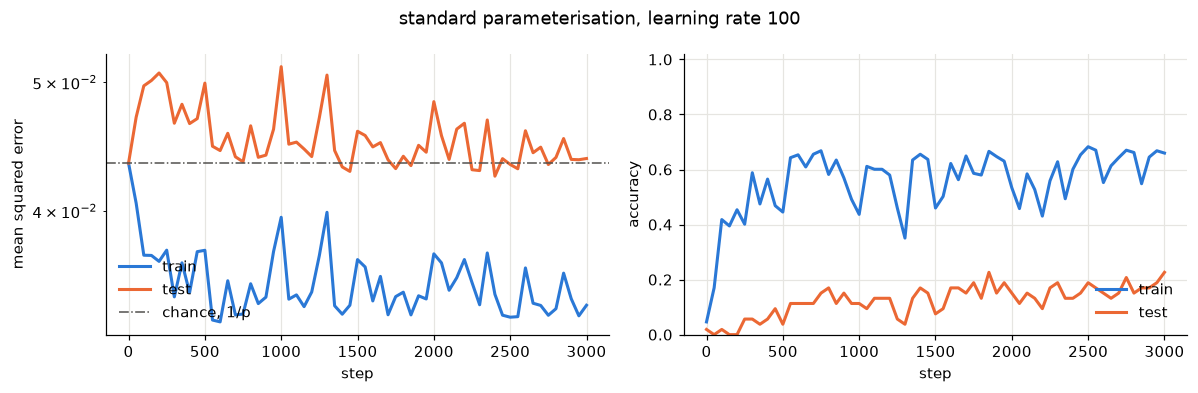

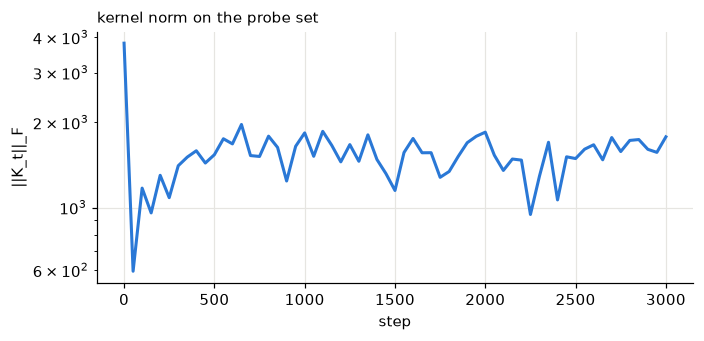

In [6]:
dead = run_or_load("standard_default_alpha1", parameterisation="standard", steps=3000, eval_interval=50)
g_dead = describe_grokking(dead)
fig = plot_losses(dead, g_dead, log_x=False, title="standard parameterisation, learning rate 100")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(dead["history"]["step"], dead["history"]["K_norm"], color=BLUE)
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("||K_t||_F")
ax.set_title("kernel norm on the probe set", loc="left", fontsize=10)
fig.tight_layout()

## 6. Tier 0 baseline in mean-field parameterisation

This is the Kumar et al. Appendix 8.3 configuration with the mean-field parameterisation of Gromov (2023) and the base learning rate `ETA_0`. Compare the loss and accuracy curves with Kumar et al., Figure 2(a) and 2(b), which run to 50,000 epochs.

mean_field_alpha1: loaded from results/mean_field_alpha1.json
mean_field_alpha1: train loss crossed 0.003 at step 5500, test loss crossed 0.003 at step 13000, grokking time 7500 steps.



Sensitivity of the grokking time to the thresholds. Dotted line is the train crossing, dashed the test crossing.
 tau_train  tau_test  t_train   t_test     t_grok
      0.01      0.01     4000     5500       1500
      0.01     0.003     4000    13000       9000
      0.01     0.001     4000        -     >96000
      0.01    0.0003     4000        -     >96000
      0.01    0.0001     4000        -     >96000
     0.003      0.01     5500     5500          0
     0.003     0.003     5500    13000       7500
     0.003     0.001     5500        -     >94500
     0.003    0.0003     5500        -     >94500
     0.003    0.0001     5500        -     >94500
     0.001      0.01     7750     5500      -2250
     0.001     0.003     7750    13000       5250
     0.001     0.001     7750        -     >92250
     0.001    0.0003     7750        -     >92250
     0.001    0.0001     7750        -     >92250
    0.0003      0.01    16000     5500     -10500
    0.0003     0.003    16000    130

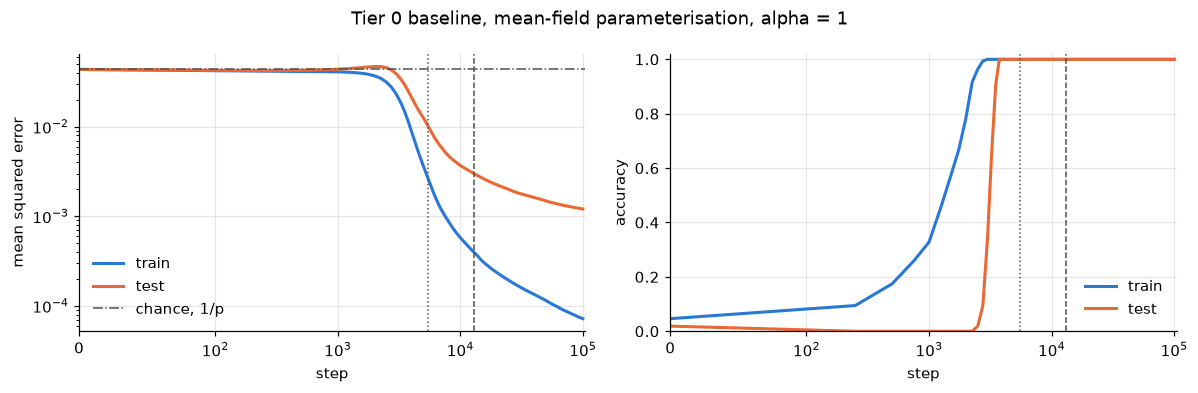

In [7]:
baseline = run_or_load("mean_field_alpha1", parameterisation="mean_field", alpha=1.0,
                       eta_0=ETA_0, steps=STEPS, eval_interval=250)
g_base = describe_grokking(baseline)
fig = plot_losses(baseline, g_base, title="Tier 0 baseline, mean-field parameterisation, alpha = 1")
print()
print("Sensitivity of the grokking time to the thresholds. Dotted line is the train crossing, dashed the test crossing.")
sensitivity_table(baseline)

## 7. Kernel measures on the baseline

The dotted line is the train-loss crossing and the dashed line is the test-loss crossing. Under the proposal's hypothesis the alignment A_t should rise before the test loss falls, and the rotation R_t should be clearly nonzero by the time it does.

At the test crossing: S_t = +5.393, R_t = 0.0408, A_t = 0.1275, A_0 = 0.0903


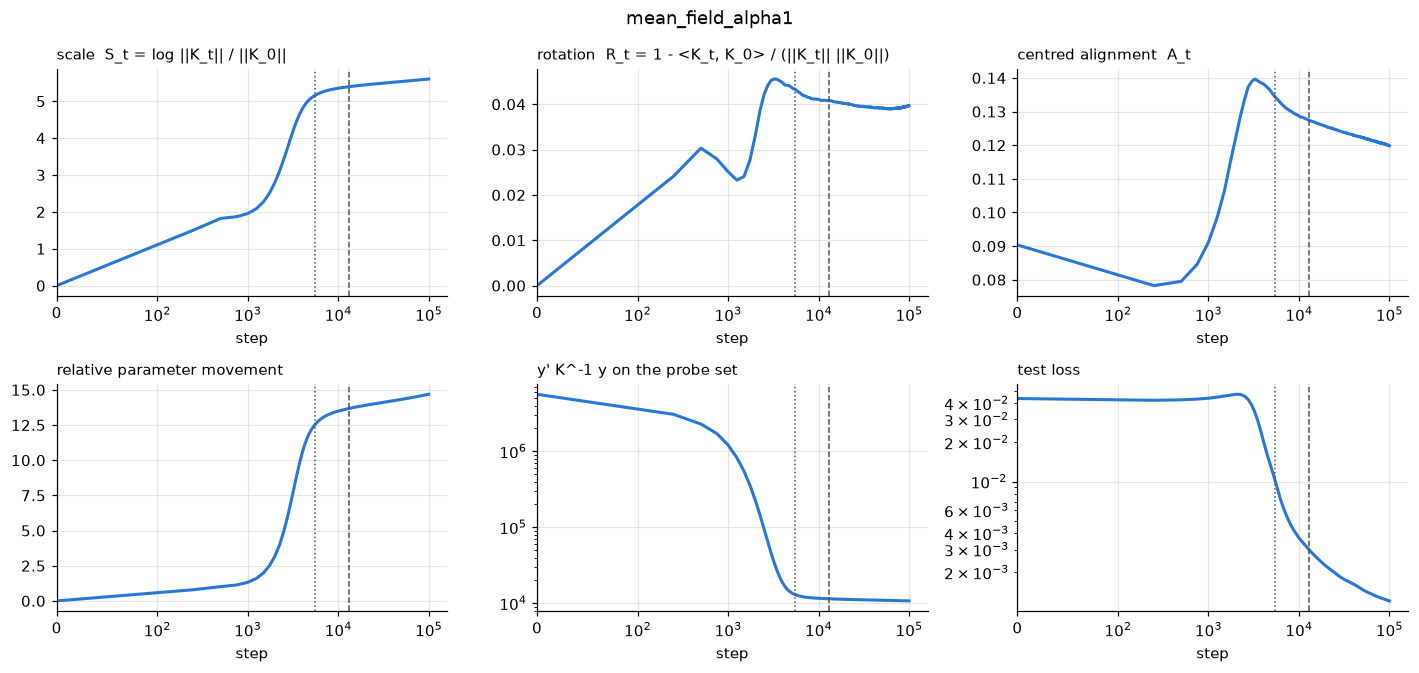

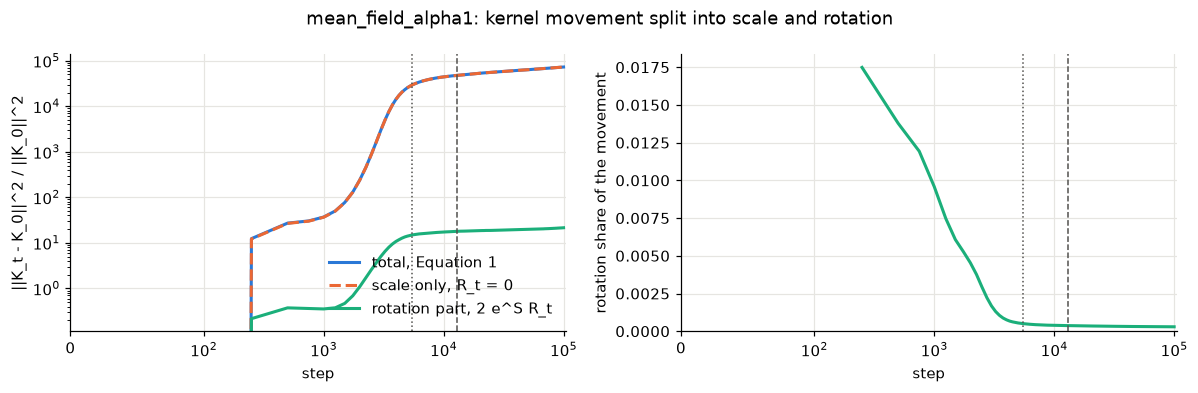

In [8]:
fig = plot_kernel_measures(baseline, g_base)
fig = plot_decomposition(baseline, g_base)
if g_base["t_test"] is not None:
    print(f"At the test crossing: S_t = {value_at_step(baseline, 'S_t', g_base['t_test']):+.3f}, "
          f"R_t = {value_at_step(baseline, 'R_t', g_base['t_test']):.4f}, "
          f"A_t = {value_at_step(baseline, 'A_t', g_base['t_test']):.4f}, "
          f"A_0 = {baseline['history']['A_t'][0]:.4f}")

## 8. Alpha sweep

Kumar et al., Figure 2(c), sweep the laziness parameter alpha over 0.5, 1, 1.5 and 2 for 100,000 epochs. The same values and length are run here, with the learning rate `ETA_0` over alpha squared. Larger alpha is lazier, so the test loss should fall later or not at all within the run. The table reports the grokking time per cell and the alignment at the moment the test loss crosses its threshold, which is a first look at whether the threshold A_* is shared across alpha.

mean_field_alpha0.5: loaded from results/mean_field_alpha0.5.json
mean_field_alpha1: loaded from results/mean_field_alpha1.json
mean_field_alpha1.5: loaded from results/mean_field_alpha1.5.json
mean_field_alpha2: loaded from results/mean_field_alpha2.json


 alpha  t_train   t_test    t_grok  A at t_test  R at t_test  S at t_test
   0.5     3000     6000      3000       0.1267       0.0417       +6.104
     1     5500    13000      7500       0.1275       0.0408       +5.393
   1.5     8000    19500     11500       0.1269       0.0397       +4.991
     2    10000    24000     14000       0.1277       0.0412       +4.687


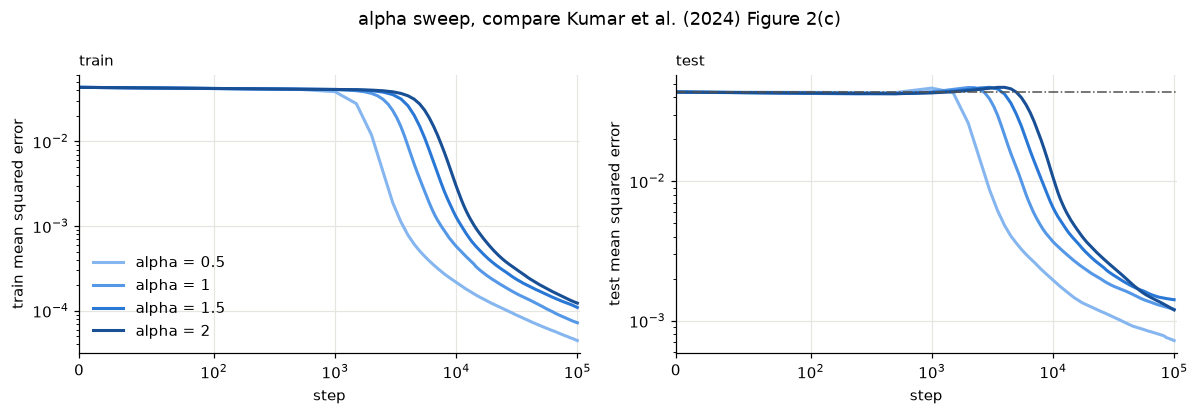

In [9]:
SWEEP_ALPHAS = [0.5, 1.0, 1.5, 2.0]
sweep = {}
for a in SWEEP_ALPHAS:
    sweep[a] = run_or_load(f"mean_field_alpha{a:g}", parameterisation="mean_field", alpha=a,
                           eta_0=ETA_0, steps=STEPS, eval_interval=500 if a != 1.0 else 250)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for colour, a in zip(ALPHA_RAMP, SWEEP_ALPHAS):
    h = sweep[a]["history"]
    axes[0].plot(h["step"], h["train_loss"], color=colour, label=f"alpha = {a:g}")
    axes[1].plot(h["step"], h["test_loss"], color=colour, label=f"alpha = {a:g}")
for ax, side in zip(axes, ["train", "test"]):
    ax.set_yscale("log")
    log_step_axis(ax)
    ax.set_xlabel("step")
    ax.set_ylabel(f"{side} mean squared error")
    ax.set_title(side, loc="left", fontsize=10)
axes[1].axhline(1 / 23, color=GRAY, lw=1, ls="-.")
axes[0].legend(loc="lower left")
fig.suptitle("alpha sweep, compare Kumar et al. (2024) Figure 2(c)")
fig.tight_layout()

print(f"{'alpha':>6} {'t_train':>8} {'t_test':>8} {'t_grok':>9} {'A at t_test':>12} {'R at t_test':>12} {'S at t_test':>12}")
for a in SWEEP_ALPHAS:
    g = grokking_time(sweep[a])
    if g["t_test"] is None:
        t_g = "-" if g["t_grok"] is None else f">{g['t_grok']}"
        print(f"{a:>6g} {str(g['t_train'] or '-'):>8} {'-':>8} {t_g:>9} {'censored':>12}")
    else:
        print(f"{a:>6g} {g['t_train']:>8} {g['t_test']:>8} {g['t_grok']:>9} "
              f"{value_at_step(sweep[a], 'A_t', g['t_test']):>12.4f} "
              f"{value_at_step(sweep[a], 'R_t', g['t_test']):>12.4f} "
              f"{value_at_step(sweep[a], 'S_t', g['t_test']):>+12.3f}")

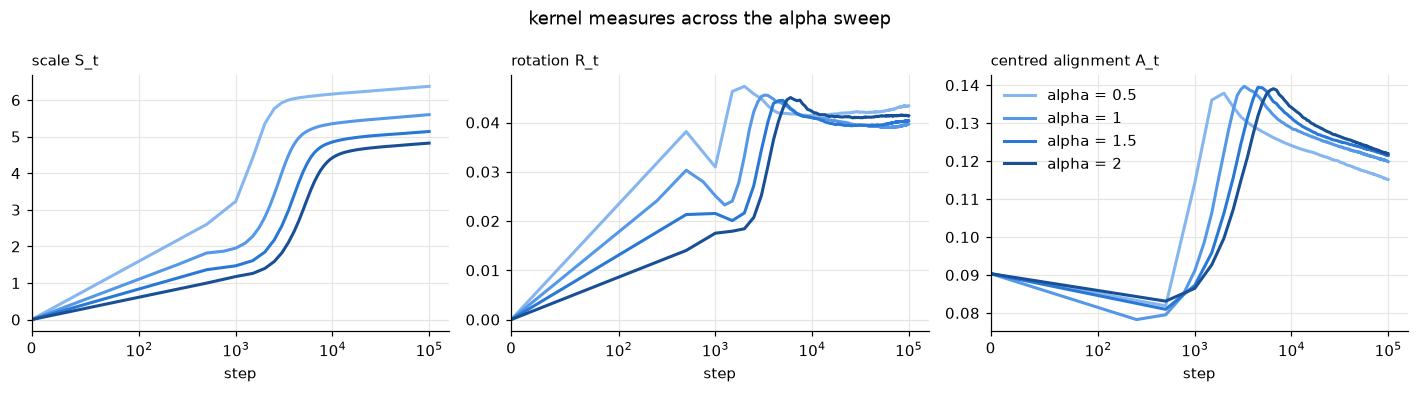

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for colour, a in zip(ALPHA_RAMP, SWEEP_ALPHAS):
    h = sweep[a]["history"]
    for ax, key in zip(axes, ["S_t", "R_t", "A_t"]):
        ax.plot(h["step"], h[key], color=colour, label=f"alpha = {a:g}")
for ax, label in zip(axes, ["scale S_t", "rotation R_t", "centred alignment A_t"]):
    ax.set_title(label, loc="left", fontsize=10)
    ax.set_xlabel("step")
    log_step_axis(ax)
axes[2].legend(loc="upper left")
fig.suptitle("kernel measures across the alpha sweep")
fig.tight_layout()

## 9. Reading the results of the 14 September 2026 run

The mean-field baseline reaches full train and test accuracy within the first few thousand steps, and the test loss falls a few thousand steps after the train loss. The gap is much shorter than the tens of thousands of epochs in Kumar et al., Figure 2, and the test loss floors near one thousandth while the train loss keeps falling. Whether this counts as a reproduction of the published figure is a question for the group. The alpha sweep behaves as Kumar et al. describe in direction, since larger alpha delays both crossings and the grokking time grows from about 3,000 steps at alpha 0.5 to about 14,000 at alpha 2, but it does not make grokking vanish within 100,000 steps. The centred alignment at the moment the test loss crosses its threshold is about 0.127 in all four cells, which is a first sign in favour of a shared threshold, though it comes from one seed and one width.

The kernel measures give one clear result for the proposal. Under this parameterisation the kernel norm grows by a factor of a few hundred, so the scale term dominates the usual movement statistic and the rotation term stays near 0.04. The rotation share of the squared relative movement is well under one percent for the whole run. The centred alignment rises from about 0.08 to about 0.14 around the time the test loss falls and then decays slowly. This is the confound the proposal describes: the standard movement statistic would report a large change that is almost all scale.

## 10. What was saved

Every run is in `results/<name>.json` with its configuration, its history at each checkpoint, and its wall-clock time. Set `RERUN = True` in the first cell to train everything again. The grokking thresholds are `TAU_TRAIN` and `TAU_TEST` in the first cell; Section 6 shows how the baseline grokking time moves with them.